# Unsupervised Learning and Recommendations with Scikit Learn

This tutorial is a part of the [Machine Learning with Python: Zero to GBMs](http://zerotogbms.com) and [Zero to Data Science Bootcamp by Jovian](https://zerotodatascience.com).

![](https://i.imgur.com/eyfi64y.png)

The following topics are covered in this tutorial:

- Overview of unsupervised learning algorithms in Scikit-learn
- Clustering algorithms: K Means, DBScan, Hierarchical clustering etc.
- Dimensionality reduction (PCA) and manifold learning (t-SNE)

### How to run the code

This tutorial is an executable [Jupyter notebook](https://jupyter.org) hosted on [Jovian](https://www.jovian.ai). You can _run_ this tutorial and experiment with the code examples in a couple of ways: *using free online resources* (recommended) or *on your computer*.

#### Option 1: Running using free online resources (1-click, recommended)

The easiest way to start executing the code is to click the **Run** button at the top of this page and select **Run on Binder**. You can also select "Run on Colab" or "Run on Kaggle", but you'll need to create an account on [Google Colab](https://colab.research.google.com) or [Kaggle](https://kaggle.com) to use these platforms.


#### Option 2: Running on your computer locally

To run the code on your computer locally, you'll need to set up [Python](https://www.python.org), download the notebook and install the required libraries. We recommend using the [Conda](https://docs.conda.io/projects/conda/en/latest/user-guide/install/) distribution of Python. Click the **Run** button at the top of this page, select the **Run Locally** option, and follow the instructions.

>  **Jupyter Notebooks**: This tutorial is a [Jupyter notebook](https://jupyter.org) - a document made of _cells_. Each cell can contain code written in Python or explanations in plain English. You can execute code cells and view the results, e.g., numbers, messages, graphs, tables, files, etc., instantly within the notebook. Jupyter is a powerful platform for experimentation and analysis. Don't be afraid to mess around with the code & break things - you'll learn a lot by encountering and fixing errors. You can use the "Kernel > Restart & Clear Output" menu option to clear all outputs and start again from the top.

## Introduction to Unsupervised Learning

Unsupervised machine learning refers to the category of machine learning techniques where models are trained on a dataset without labels. Unsupervised learning is generally use to discover patterns in data and reduce high-dimensional data to fewer dimensions. Here's how unsupervised learning fits into the landscape of machine learning algorithms([source](https://medium.datadriveninvestor.com/machine-learning-in-10-minutes-354d83e5922e)):

<img src="https://miro.medium.com/max/842/1*tlQwBmbL6RkuuFq8OPJofw.png" width="640">

Here are the topics in machine learning that we're studying in this course ([source](https://vas3k.com/blog/machine_learning/)): 

<img src="https://i.imgur.com/VbVFAsg.png" width="640">

Scikit-learn offers the following cheatsheet to decide which model to pick for a given problem. Can you identify the unsupervised learning algorithms?

![](https://scikit-learn.org/stable/_static/ml_map.png)

Here is a full list of unsupervised learning algorithms available in Scikit-learn: https://scikit-learn.org/stable/unsupervised_learning.html

## Clustering 

Clustering is the process of grouping objects from a dataset such that objects in the same group (called a cluster) are more similar (in some sense) to each other than to those in other groups ([Wikipedia](https://en.wikipedia.org/wiki/Cluster_analysis)). Scikit-learn offers several clustering algorithms. You can learn more about them here: https://scikit-learn.org/stable/modules/clustering.html

Here is a visual representation of clustering:
|
<img src="https://i.imgur.com/VXPgw6H.png" width="400">


Here are some real-world applications of clustering:

* Customer segmentation 
* Product recommendation
* Feature engineering
* Anomaly/fraud detection
* Taxonomy creation

We'll use the [Iris flower dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) to study some of the clustering algorithms available in `scikit-learn`. It contains various measurements for 150 flowers belonging to 3 different species.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline

In [12]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


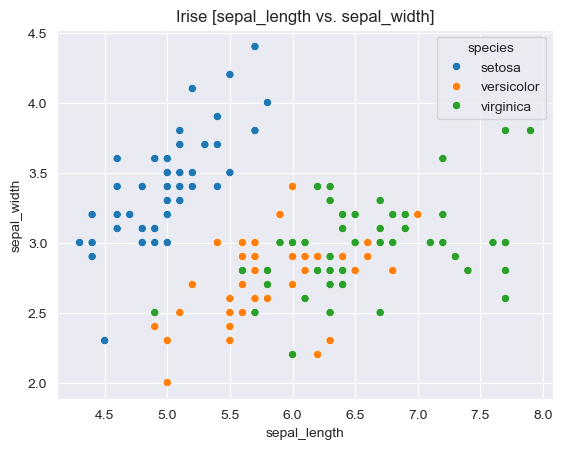

In [13]:
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='species')
plt.title('Irise [sepal_length vs. sepal_width]')
plt.show()

We'll attempt to cluster observations using numeric columns in the data. 

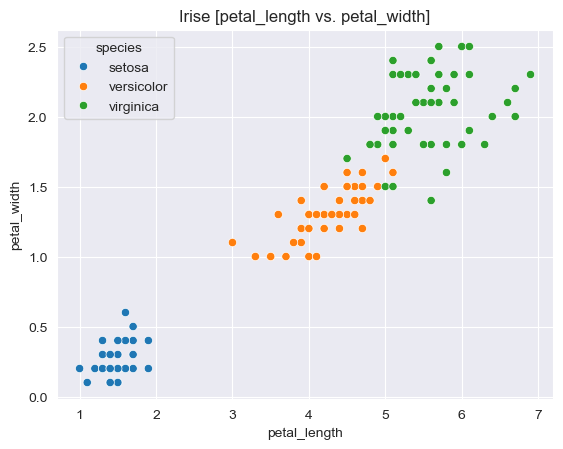

In [15]:
sns.scatterplot(data=iris_df, x='petal_length', y='petal_width', hue='species')
plt.title('Irise [petal_length vs. petal_width]')
plt.show()

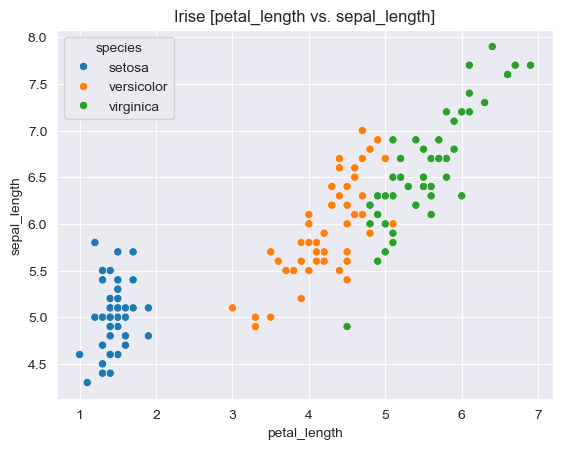

In [16]:
sns.scatterplot(data=iris_df, x='petal_length', y='sepal_length', hue='species')
plt.title('Irise [petal_length vs. sepal_length]')
plt.show()

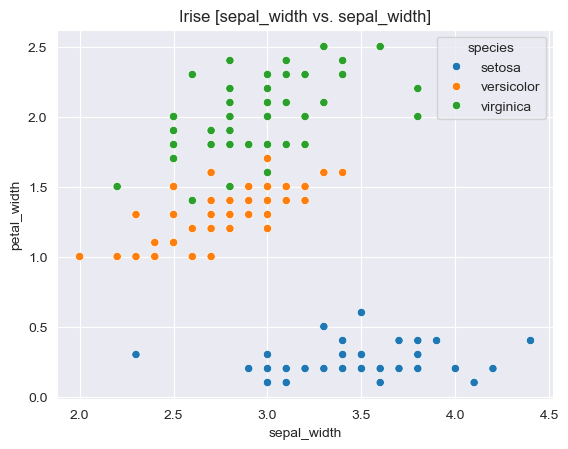

In [17]:
sns.scatterplot(data=iris_df, x='sepal_width', y='petal_width', hue='species')
plt.title('Irise [sepal_width vs. sepal_width]')
plt.show()

In [18]:
iris_df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

In [19]:
iris_df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [20]:
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris_df[numeric_cols]

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(iris_df[numeric_cols])
X[numeric_cols] = scaler.transform(iris_df[numeric_cols])

C:\Users\aa\AppData\Local\Temp\ipykernel_4080\1191919641.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = scaler.transform(iris_df[numeric_cols])


### K Means Clustering

The K-means algorithm attempts to classify objects into a pre-determined number of clusters by finding optimal central points (called centroids) for each cluster. Each object is classifed as belonging the cluster represented by the closest centroid.

<img src="https://miro.medium.com/max/1400/1*rw8IUza1dbffBhiA4i0GNQ.png" width="640">

Here's how the K-means algorithm works:

1. Pick K random objects as the initial cluster centers.
2. Classify each object into the cluster whose center is closest to the point.
3. For each cluster of classified objects, compute the centroid (mean).
4. Now reclassify each object using the centroids as cluster centers.
5. Calculate the total variance of the clusters (this is the measure of goodness).
6. Repeat steps 1 to 6 a few more times and pick the cluster centers with the lowest total variance.

Here's a video showing the above steps: https://www.youtube.com/watch?v=4b5d3muPQmA

In [24]:
from sklearn.cluster import KMeans

In [25]:
?KMeans

Init signature:
KMeans(
    n_clusters=8,
    *,
    init='k-means++',
    n_init='auto',
    max_iter=300,
    tol=0.0001,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm='lloyd',
)
Docstring:     
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

    For an example of how to choose an optimal value for `n_clusters` refer to
    :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    * 'k-means++' : selects initial cluster centroids using sampling             based on an empirical probability distribution of the points'             contribution to the overall inertia. This technique speeds up             convergence. The algorithm imple

- n_clusters=8  
  عدد المجموعات (العنقود) التي تريد تقسيم البيانات إليها.

- init='k-means++'  
  طريقة اختيار مراكز العناقيد الأولية لتحسين سرعة وجودة التجميع. k-means++ هي الطريقة الأكثر استخدامًا وهي تحسن النتائج عن الاختيار العشوائي.

- n_init='auto'  
  عدد المرات التي سيتم فيها تكرار الخوارزمية باستخدام مراكز ابتدائية مختلفة، ثم يتم اختيار أفضل نتيجة. إعداد auto يعني اختيار تلقائي للقيمة المناسبة.

- max_iter=300  
  الحد الأقصى لعدد التكرارات التي ستقوم بها الخوارزمية لكل محاولة للوصول إلى المركز الأمثل.

- tol=0.0001  
  معيار التوقف؛ إذا تغيرت المجموعات أو مراكزها أقل من هذا الحد، يتوقف الخوارزم.

- verbose=0  
  مستوى التفاصيل التي تريد ظهورها أثناء التشغيل. 0 يعني لا يظهر تفاصيل.

- random_state=None  
  زر العشوائية لتكرار النتائج. إذا حددت قيمة معينة، تحصل على نتائج متكررة.

- copy_x=True  
  تحديد هل تريد نسخ البيانات أم تعديلها مباشرة.

- algorithm='lloyd'  
  الخوارزمية المستخدمة للحساب، lloyd هي الأكثر شيوعًا.


In [27]:
model = KMeans(n_clusters=3, random_state=42)

In [28]:
model.fit(X)

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [29]:
#  مركز كل كلاستر لاربع ابعاد (نقطه باربع ابعاد)
model.cluster_centers_

array([[0.66773504, 0.44310897, 0.7571708 , 0.78205128],
       [0.19611111, 0.595     , 0.07830508, 0.06083333],
       [0.41203704, 0.27690972, 0.55896893, 0.52083333]])

In [30]:
preds = model.predict(X)
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0])

In [31]:
len(preds[preds ==2])

48

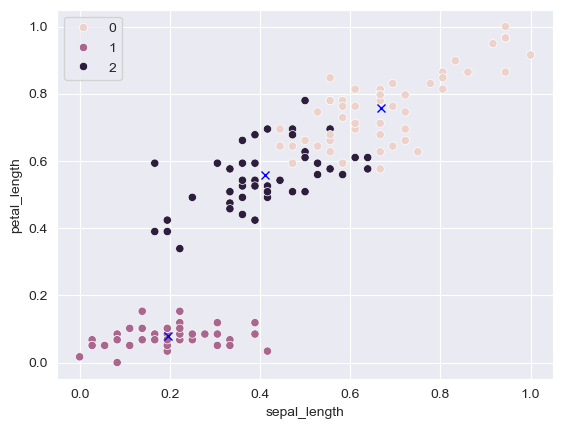

In [32]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds);
centers_x, centers_y = model.cluster_centers_[:,0], model.cluster_centers_[:,2]
plt.plot(centers_x, centers_y, 'xb')

In [33]:
model.cluster_centers_[:,0]

array([0.66773504, 0.19611111, 0.41203704])

In [34]:
model.cluster_centers_

array([[0.66773504, 0.44310897, 0.7571708 , 0.78205128],
       [0.19611111, 0.595     , 0.07830508, 0.06083333],
       [0.41203704, 0.27690972, 0.55896893, 0.52083333]])

As you can see, K-means algorithm was able to classify (for the most part) different specifies of flowers into separate clusters. Note that we did not provide the "species" column as an input to `KMeans`.

We can check the "goodness" of the fit by looking at `model.inertia_`, which contains the sum of squared distances of samples to their closest cluster center. Lower the inertia, better the fit.

In [37]:
#  يخبرنا بمقدار انتشار البيانات
#  كلما كان الانتشار داخل مجموعه البيانات اقل, كلما كانت جودة الملائمه افضل
model.inertia_

7.122750172943849

In [38]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(X)
preds = model.predict(X)
preds

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0])

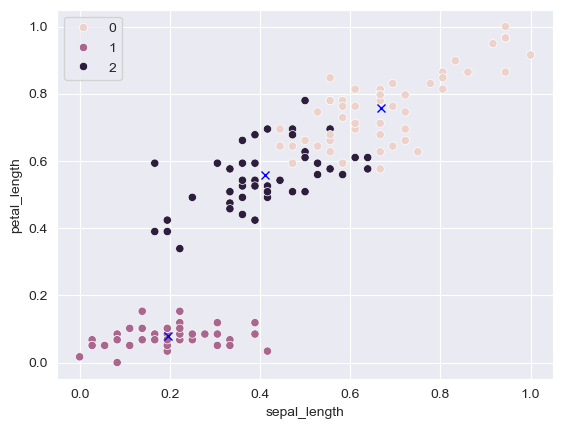

In [39]:
# عند القيام بالتجميع قد تكتشف اشياء مهمه حتى لو وجد لابيل 
# حتى لو وجد لابيل عند التقسيم قد يعطي كلاستر اكثر يكون لائم البيانات اكثر
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=preds);
centers_x, centers_y = model.cluster_centers_[:,0], model.cluster_centers_[:,2]
plt.plot(centers_x, centers_y, 'xb')

In [40]:
model.inertia_

7.122750172943849

In most real-world scenarios, there's no predetermined number of clusters. In such a case, you can create a plot of "No. of clusters" vs "Inertia" to pick the right number of clusters.

C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

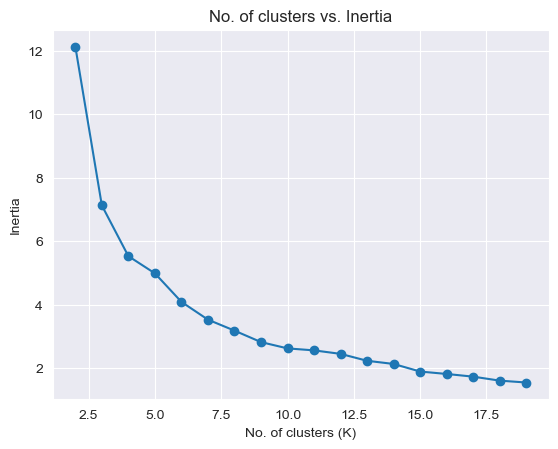

In [42]:
#  نختار افضل قيمه بحيث عند وجود انحدار قوي نختار التي بعدها وهكذا حتى يصبح الانحدار ضعيف هنا افضل قيمه هي 6
options = range(2,20)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters, random_state=42).fit(X)
    inertias.append(model.inertia_)
    
plt.title("No. of clusters vs. Inertia")
plt.plot(options, inertias, '-o')
plt.xlabel('No. of clusters (K)')
plt.ylabel('Inertia');

The chart is creates an "elbow" plot, and you can pick the number of clusters beyond which the reduction in inertia decreases sharply.

**Mini Batch K Means**: The K-means algorithm can be quite slow for really large dataset. Mini-batch K-means is an iterative alternative to K-means that works well for large datasets. Learn more about it here: https://scikit-learn.org/stable/modules/clustering.html#mini-batch-kmeans


> **EXERCISE**: Perform clustering on the [Mall customers dataset](https://www.kaggle.com/vjchoudhary7/customer-segmentation-tutorial-in-python) on Kaggle. Study the segments carefully and report your observations.

%%time
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
# النموذج الأساسي
KMeans = KMeans(random_state=42)

# شبكة البحث
param_grid = {
    'n_clusters': [i for i in range(1,20)],
    'max_iter': [100, 200, 300, 400, 500],
    'tol': [0.0001],
}

# تهيئة GridSearchCV
grid_search = GridSearchCV(estimator=KMeans, param_grid=param_grid, cv=5, verbose=0)

# fit على بياناتك (مثال: X_train, y_train)
grid_search.fit(X)

# أفضل المعاملات
print("Best params:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)


- RI/ARI: تركيز على الأزواج من النقاط وكيف تم تجميعها.  
- NMI: يعتمد على كمية المعلومات المشتركة بين المجموعات.  
- Purity: يركز على نسبة النقاط المصنفة بشكل صحيح في كل عنقود.

Purity check

<p> To compute purity , each cluster is assigned to the class which is most frequent in the cluster, and then the accuracy of this assignment is measured by counting the number of correctly assigned documents and dividing by N. </p>

- مقياy يتراوح بين 0 و 1، وكلما قرب من 1، كان التجميع أفضل و أكثر تطابقًا مع التسميات الحقيقي 

In [49]:
from sklearn.metrics.cluster import contingency_matrix, adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import numpy as np
def purity_score(y, y_pred):
    # compute confusion matrix
    confusion_matrix = contingency_matrix(y, y_pred)
    # return purity
    return np.sum(np.amax(confusion_matrix, axis=0)) / np.sum(confusion_matrix) 
purity_score(iris_df.species, preds)

0.88

NMI check

<p> Normalized Mutual Information (NMI) is a normalization of the Mutual Information (MI) score to scale the results between 0 (no mutual information) and 1 (perfect correlation). In this function, mutual information is normalized by some generalized mean of H(labels_true) and H(labels_pred)) </p>

- هو مقياس لتقييم جودة التجميع (Clustering) يعتمد على معلومات مشتركة بين التسميات الحقيقية (iris_df.species) والتسميات المتوقعة (preds).
- يقيس كمية المعلومات التي يشترك فيها التصنيف الحقيقي وتصنيف التجميع.
- قيمته تكون بين 0 و 1:
  - 0 يعني لا تشابه أبداً بين التصنيفين.  
  - 1 يعني تطابق كامل بين التصنيفين.

In [51]:
nmi = normalized_mutual_info_score(iris_df.species, preds)
nmi

0.7144576477818988

Rand Index check

<p> Adjusted Rand Score on the other hand, computes a similarity measure between two clusters by considering all pairs of samples and counting pairs that are assigned in the same or different clusters in the predicted and true clusters. </p>


- ARI يقيس تشابه التجميع مع التصنيفات الحقيقية، مع تعديل للتوافق العشوائي.  
- قيمته تتراوح بين -1 و 1:
  - 1 تعني تطابق كامل بين التجميع والتصنيف الحقيقي.
  - 0 تعني توافق عشوائي (أي النتائج مثل ما لو قسّمت البيانات عشوائياً).  
  - قيم أقل من 0 تعني أن التجميع سيء وغير متوافق.

In [53]:
rand = adjusted_rand_score(iris_df.species, preds)
rand

0.7008666982225341

In [54]:
from sklearn.metrics import silhouette_score
silhouette_score(X, preds)

0.48292893354301647

In [55]:
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0])

In [56]:
len(preds[preds ==0])

52

### DBSCAN

Density-based spatial clustering of applications with noise (DBSCAN) uses the density of points in a region to form clusters. It has two main parameters: "epsilon" and "min samples" using which it classifies each point as a core point, reachable poin(Border points) t or noise point (outlier).

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/DBSCAN-Illustration.svg/800px-DBSCAN-Illustration.svg.png" width="400">

Here's a video explaining how the DBSCAN algorithm works: https://www.youtube.com/watch?v=C3r7tGRe2eI

- نحدد قيمة ابسيلون 0.5 و الحد الادنى للعينات 4
- نختار اي نقطه ونرسم دائره حول هذه النقطه بنصف قطر ابسيلون
- ثم نتحقق اذا كان داخل الدائره 4 نقاط على الاقل
- وجميع النقاط داخل الدائره متصلة بها ثم ننتقل الى نقطة اخرى core point اذا كان يوجد تسمى
- reachable point التي لا تحتوي على اربع نقاط فاكثر لا تسمى نقطه رئيسيه واذا وجد على الاقل نقطه رئيسيه داخل الدائره واذا كانت متصله بنقطه رئيسية تسمى
-  Noise point  اذا لم يوجد الاحد الادنى من النقاط ولا يوجد نقطه رئيسية تسمى
-  لا تعاملها الخوارزميه كمجموعه منفصله للقيم الشاذه قيم الضجيج-
- النقاط التي تتصل ببعض تنتمي لكلاستر واحد
- noise point (outlier)  عند رسم دائره حول نقطه ولا تحتوي على اي نقاط داخلها تسمى
- يتم تعريق المجموعه (الكلاستر) من خلال الاتصال بين النقاط

- Advantages of DBSCAN:

1. جيدة في فصل مجموعات الكثافه العاليه وتركز على الكثافه العاليه للنقاط مقابل الكثافه المنخفضه
2. جيده في التحديد والتعامل مع النقاط المتطرفه

- Disadvantages of DBSCAN:

1. لا تعمل بشكل جيد في التعامل مع المجموعات حيث تكون حث تكون الكثافه عاليه جدا
نفترض انه اذا كان لدي بعض الكثافه الكثيفه للغايه في مجموعاتي في لي وقت اذا كان لدي عدد قليل من المجموعتن الكثيفه فان كل هذا
النوع من الارتفاع لن تعمل الخوارميه بشكل جيد
2. اذا كانت الابعاد كبيره يصبح من الصعب تجميعها

In [60]:
from sklearn.cluster import DBSCAN

In [61]:
DBSCAN?

Init signature:
DBSCAN(
    eps=0.5,
    *,
    min_samples=5,
    metric='euclidean',
    metric_params=None,
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None,
)
Docstring:     
Perform DBSCAN clustering from vector array or distance matrix.

DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
Finds core samples of high density and expands clusters from them.
Good for data which contains clusters of similar density.

The worst case memory complexity of DBSCAN is :math:`O({n}^2)`, which can
occur when the `eps` param is large and `min_samples` is low.

Read more in the :ref:`User Guide <dbscan>`.

Parameters
----------
eps : float, default=0.5
    The maximum distance between two samples for one to be considered
    as in the neighborhood of the other. This is not a maximum bound
    on the distances of points within a cluster. This is the most
    important DBSCAN parameter to choose appropriately for your data set
    and distance function.

min_s

1. eps=0.5  
   نصف قطر الجوار (بالنسبة للمسافة). النقاط التي تقع ضمن هذا النطاق من نقطة ما تعتبر جيران لها.  
   كلما قل الـ eps، زادت دقة المجموعات ولكن قد يظهر المزيد من الضوضاء (النقاط الشاذة).
- افضل قيمه هي عدد الاعمده زائد واحد او اكبر
2. min_samples=5  
   الحد الأدنى من عدد النقاط (بما في ذلك النقطة نفسها) التي يجب أن تكون ضمن مسافة eps ليتم اعتبار النقطة نقطة مركزية (Core Point).  
   كلما زاد هذا الرقم، زادت الصرامة في تحديد المجموعات.

3. metric='euclidean'  
   مقياس المسافة المستخدم لحساب المسافات بين النقاط.  
   افتراضياً يُستخدم المقياس الإقليدي (Euclidean distance)، يمكن تغييره إلى مقاييس أخرى مثل Manhattan، Minkowski، أو حتى تخصيص مقياس خاص.

4. metric_params=None  
   معلمات إضافية يمكن تمريرها إلى دالة حساب المسافة، تُستخدم فقط إذا كان هناك حاجة لتخصيص وظيفة المسافة.

5. algorithm='auto'  
   الخوارزمية المستخدمة لحساب الجيران:  
   - 'auto': تعطي أفضل اختيار بناءً على البيانات.  
   - خيارات أخرى: 'ball_tree', 'kd_tree', 'brute'.  
   تُستخدم لتسريع حساب المسافات في البيانات الكبيرة.

6. leaf_size=30  
   حجم الورقة في هياكل البيانات (Ball Tree أو KD Tree) المستخدمة لتسريع عمليات البحث عن الجيران.  
   يؤثر على سرعة وذاكرة التنفيذ.

7. p=None  
   إذا كان metric هو Minkowski، تحدد قيمة الـ p لمقياس المسافة (p=1 لمنهتن، p=2 لإقليدي).  
   إذا metric ليست Minkowski، يتم تجاهل هذه القيمة.

8. n_jobs=None  
   عدد الوظائف (المعالجات) التي يمكن استخدامها في حساب المسافات بشكل متوازي.  
   - None أو 1 يعني استخدام معالج واحد فقط.  
   - قيم أخرى (مثل -1) تعني استخدام كل المعالجات المتاحة لتسريع العملية.


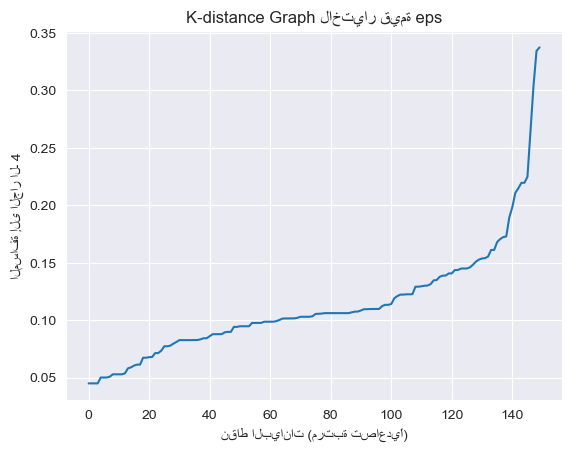

In [63]:
from sklearn.neighbors import NearestNeighbors

# عدد الجيران k (عادة = min_samples - 1)
k = 4  # إذا min_samples=5

# إنشاء نموذج NearestNeighbors للبحث عن k أقرب جيران
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

# نحصل على المسافة للنقطة k الأقرب (أي المسافة إلى الجار الرابع)
k_distances = distances[:, k-1]

# ترتيب المسافات تصاعديًا
k_distances = np.sort(k_distances)

# رسم المنحنى
plt.plot(k_distances)
plt.xlabel('نقاط البيانات (مرتبة تصاعديًا)')
plt.ylabel(f'المسافة إلى الجار الـ {k}')
plt.title('K-distance Graph لاختيار قيمة eps')
plt.grid(True)
plt.show()


In [64]:
model = DBSCAN(eps=.4, min_samples=5)
model.fit(X)

DBSCAN(eps=0.4)

In DBSCAN, there's no prediction step. It directly assigns labels to all the inputs.

In [66]:
dir(model)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'algorithm',
 'components_',
 'core_sample_indices_',
 'eps',
 'feature_names_in_',
 'fit',
 'fit_predict',
 'get_metadata_routin

In [67]:
#  جميع النقاط الاساسيه
model.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149], dtype=int64)

In [68]:
model.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [69]:
labels = model.fit_predict(X)
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int64)

In [70]:
from sklearn.metrics import silhouette_score
silhouette_score(X, model.labels_)

0.6300471284354711

In [71]:
silhouette_score(X, labels)

0.6300471284354711

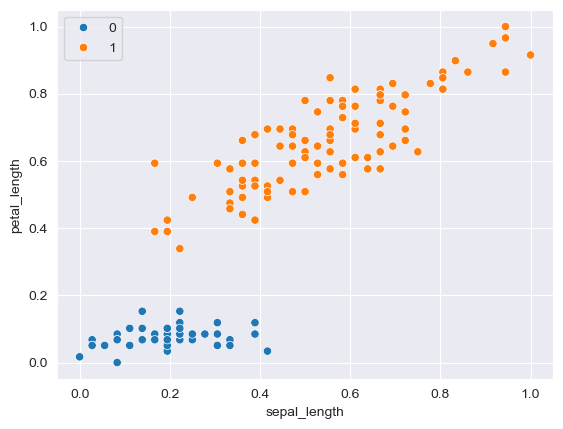

In [72]:
sns.scatterplot(data=X, x='sepal_length', y='petal_length', hue=model.labels_);

> **EXERCISE**: Try changing the values of `eps` and `min_samples` and observe how the number of clusters the classification changes.

Here's how the results of DBSCAN and K Means differ:

<img src="https://miro.medium.com/max/1339/0*xu3GYMsWu9QiKNOo.png" width="640">

### Hierarchical Clustering

Hierarchical clustering, as the name suggests, creates a hierarchy or a tree of clusters.

<img src="https://dashee87.github.io/images/hierarch.gif" width="640">

While there are several approaches to hierarchical clustering, the most common approach works as follows:

1. Mark each point in the dataset as a cluster.
2. Pick the two closest cluster centers without a parent and combine them into a new cluster. 
3. The new cluster is the parent cluster of the two clusters, and its center is the mean of all the points in the cluster.
3. Repeat steps 2 and 3 till there's just one cluster left.

Watch this video for a visual explanation of hierarchical clustering: https://www.youtube.com/watch?v=7xHsRkOdVwo

-  Heatmap يرتبط ب
-  بحيث تحتوي على العينات مع الجينات
-  نرى التشابه عن طريق المسافة الاقليدية

> **EXERCISE**: Implement hierarchical clustering for the Iris dataset using `scikit-learn`.

There are several other clustering algorithms in Scikit-learn. You can learn more about them and when to use them here: https://scikit-learn.org/stable/modules/clustering.html

## Dimensionality Reduction and Manifold Learning

In machine learning problems, we often encounter datasets with a very large number of dimensions (features or columns). Dimensionality reduction techniques are used to reduce the number of dimensions or features within the data to a manageable or convenient number. 


Applications of dimensionality reduction:

* Reducing size of data without loss of information
* Training machine learning models efficiently
* Visualizing high-dimensional data in 2/3 dimensions
* خاصة مع بيانات المستشعر
* تقليل الابعاد دون فقدان المعلومات

### Principal Component Analysis (PCA)

Principal component is a dimensionality reduction technique that uses linear projections of data to reduce their dimensions, while attempting to maximize the variance of data in the projection. Watch this video to learn how PCA works: https://www.youtube.com/watch?v=FgakZw6K1QQ

Here's an example of PCA to reduce 2D data to 1D:

<img src="https://i.imgur.com/ZJ7utlo.png" width="480">

Here's an example of PCA to reduce 3D data to 2D:

<img src="https://lihan.me/assets/images/pca-illustration.png" width="640">


Let's apply Principal Component Analysis to the Iris dataset.

In [81]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [82]:
numeric_cols

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [83]:
 from sklearn.decomposition import PCA

In [84]:
?PCA

Init signature:
PCA(
    n_components=None,
    *,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=None,
)
Docstring:     
Principal component analysis (PCA).

Linear dimensionality reduction using Singular Value Decomposition of the
data to project it to a lower dimensional space. The input data is centered
but not scaled for each feature before applying the SVD.

It uses the LAPACK implementation of the full SVD or a randomized truncated
SVD by the method of Halko et al. 2009, depending on the shape of the input
data and the number of components to extract.

It can also use the scipy.sparse.linalg ARPACK implementation of the
truncated SVD.

Notice that this class does not support sparse input. See
:class:`TruncatedSVD` for an alternative with sparse data.

For a usage example, see
:ref:`sphx_glr_auto_examples_decomposition_plot_pca_iris.py`

Read more in the 

### 1. n_components  
- الوصف: عدد المكونات الرئيسية التي تريد الاحتفاظ بها بعد التحليل.  
- القيم:  
  - None (افتراضي): يحتفظ بجميع المكونات (عددها يساوي عدد الميزات الأصلية).  
  - قيمة صحيحة: عدد معين من المكونات، مثلاً 2 يعني الاحتفاظ بأول مكونين.  
  - نسبة عشرية بين 0 و 1: تحفظ عدد المكونات التي تفسر على الأقل هذه النسبة من التباين.  
- الأهمية: مهم جداً لتقليل الأبعاد مع الحفاظ على أكبر قدر ممكن من المعلومات.

---

### 2. copy  
- الوصف: هل تقوم بنسخ البيانات قبل التحليل أم لا.  
- القيم:  
  - True (افتراضي): ينسخ البيانات.  
  - False: لا ينسخ، ولكن قد يؤثر على البيانات الأصلية.  
- الأهمية: في العادة تتركه True لتحقيق سلامة البيانات الأصلية.

---

### 3. whiten  
- الوصف: هل تقوم بتبييض البيانات، أي جعل المكونات مستقلة بالإضافة إلى التطبيع إلى تباين واحد لكل مكون.  
- القيم:  
  - False (افتراضي): لا يتم التبييض.  
  - True: يتم التبييض.  
- الأهمية:  
  التبييض مفيد في بعض نماذج التعلم الآلي حيث يكون التباين الموحد مطلوباً، لكنه يؤدي إلى فقدان بعض المعلومات الأصلية.

---

### 4. svd_solver  
- الوصف: الطريقة المستخدمة لحساب التحليل (SVD).  
- القيم:  
  - 'auto' (افتراضي): يختار الطريقة المناسبة تلقائياً حسب البيانات.  
  - 'full': حل SVD كامل.  
  - 'arpack': يستخدم خوارزمية آرپاك (مناسب للمكونات القليلة).  
  - 'randomized': خوارزمية عشوائية أسرع مع بيانات كبيرة.  
- الأهمية: اختيار الطريقة يؤثر على سرعة الحساب ودقته.

---

### 5. tol  
- الوصف: قيمة العتبة (Tolerance) التي تستخدمها خوارزمية آرپاك لمعايير التوقف.  
- القيم: رقم عشري، عادة 0.0 أو قيمة صغيرة.  
- الأهمية: تهم عند استخدام svd_solver = 'arpack' فقط.

---

### 6. iterated_power  
- الوصف: عدد تكرارات الخوارزمية العشوائية لتقريب SVD.  
- القيم:  
  - عدد صحيح أو 'auto' (افتراضي).  
- الأهمية: زيادة القيمة تعني دقة أكبر مع وقت أطول.

---

### 7. n_oversamples  
- الوصف: عدد العينات الإضافية المستخدمة في تخمين الخوارزمية العشوائية.  
- القيم: عدد صحيح (افتراضي 10).  
- الأهمية: لتحسين دقة النتائج عند استخدام svd_solver = 'randomized'.

---

### 8. poweriterationnormalizer  
- الوصف: طريقة تطبيع تكرارات القوة (power iteration).  
- القيم:  
  - 'auto' (افتراضي)  
  - 'QR'  
  - 'LU'  
  - 'none'  
- الأهمية: يؤثر على استقرار الخوارزمية ودقتها.

---

### 9. random_state  
- الوصف: قيمة لتوليد أعداد عشوائية لضبط ثبات نتائج الخوارزمية إذا تم استخدام svd_solver='randomized'.  
- القيم:  
  - رقم صحيح (مثل 42)  
  - None (افتراضي)  
- الأهمية: مهم للتكرار وإعادة الإنتاج عندما تستخدم حلول عشوائية.


In [86]:
pca = PCA(n_components=2)

In [87]:
pca.fit(iris_df[numeric_cols])

PCA(n_components=2)

In [88]:
transformed = pca.transform(iris_df[numeric_cols])
transformed

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

<Axes: >

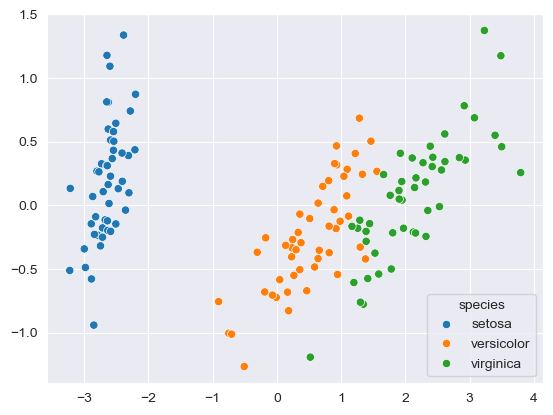

In [89]:
sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=iris_df.species)

<Axes: >

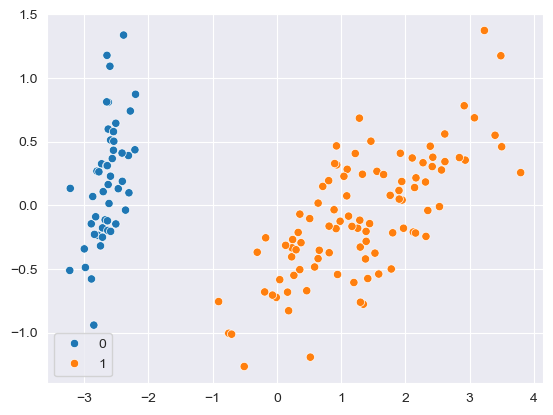

In [90]:
sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=model.labels_)

In [91]:
#  تتحكم في الاتجاه الصف الاول في اتجاه الخط الاول والصف الثاني في اتجاه الخط الثاني
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

As you can see, the PCA algorithm has done a very good job of separating different species of flowers using just 2 measures.

> **EXERCISE**: Apply Principal Component Analysis to a large high-dimensional dataset and train a machine learning model using the low-dimensional results. Observe the changes in the loss and training time for different numbers of target dimensions.

Learn more about Principal Component Analysis here: https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html

As you can see, the flowers from the same species are clustered very closely together. The relative distance between the species is also conveyed by the gaps between the clusters.

### t-Distributed Stochastic Neighbor Embedding (t-SNE)

Manifold learning is an approach to non-linear dimensionality reduction. Algorithms for this task are based on the idea that the dimensionality of many data sets is only artificially high. Scikit-learn provides many algorithms for manifold learning: https://scikit-learn.org/stable/modules/manifold.html . A commonly-used manifold learning technique is t-Distributed Stochastic Neighbor Embedding or t-SNE, used to visualize high dimensional data in one, two or three dimensions. 

Here's a visual representation of t-SNE applied to visualize 2 dimensional data in 1 dimension:

<img src="https://i.imgur.com/rVMAaix.png" width="360">


Here's a visual representation of t-SNE applied to the MNIST dataset, which contains 28px x 28px images of handrwritten digits 0 to 9, a reduction from 784 dimensions to 2 dimensions ([source](https://colah.github.io/posts/2014-10-Visualizing-MNIST/)):

<img src="https://indico.io/wp-content/uploads/2015/08/mnist-1024x607-1.jpg" width="640">

Here's a video explaning how t-SNE works: https://www.youtube.com/watch?v=NEaUSP4YerM

1.      TSNE  ثم يطبق  PCA   اولا يطبق
2.  ليست مفيده للتعلم الالي او تحليل البيانات ولكن مفيده للتصور
3.  فعاله في اكتشاف المجموعات الكلاستر في بعدين
4.  يستخدم بعدين من التوزيع في حساباته التشابه الابعاد العاليه يستخدم الغاوسي والمنخفضه يستخدم الطلابي
5.  هدفنا تقليل الاختلاف بين هذين التشابه
6.  لا يمكننا تصوير اكثر من ثلاث ابعاد

In [153]:
from sklearn.manifold import TSNE

In [157]:
?TSNE

Init signature:
TSNE(
    n_components=2,
    *,
    perplexity=30.0,
    early_exaggeration=12.0,
    learning_rate='auto',
    n_iter=1000,
    n_iter_without_progress=300,
    min_grad_norm=1e-07,
    metric='euclidean',
    metric_params=None,
    init='pca',
    verbose=0,
    random_state=None,
    method='barnes_hut',
    angle=0.5,
    n_jobs=None,
)
Docstring:     
T-distributed Stochastic Neighbor Embedding.

t-SNE [1] is a tool to visualize high-dimensional data. It converts
similarities between data points to joint probabilities and tries
to minimize the Kullback-Leibler divergence between the joint
probabilities of the low-dimensional embedding and the
high-dimensional data. t-SNE has a cost function that is not convex,
i.e. with different initializations we can get different results.

It is highly recommended to use another dimensionality reduction
method (e.g. PCA for dense data or TruncatedSVD for sparse data)
to reduce the number of dimensions to a reasonable amount (e

In [155]:
tsne = TSNE(n_components=2)

In [159]:
transformed = tsne.fit_transform(iris_df[numeric_cols])
transformed

array([[-23.875437  ,  -1.4305894 ],
       [-21.332832  ,  -2.5229647 ],
       [-21.183956  ,  -1.3164853 ],
       [-20.842545  ,  -1.61192   ],
       [-23.845785  ,  -0.9457335 ],
       [-25.833662  ,  -0.9249592 ],
       [-21.434713  ,  -0.7261155 ],
       [-23.135448  ,  -1.5997264 ],
       [-20.077644  ,  -1.7236085 ],
       [-21.728899  ,  -2.2258704 ],
       [-25.438894  ,  -1.6185867 ],
       [-22.392347  ,  -1.1686792 ],
       [-20.983025  ,  -2.2591443 ],
       [-19.860811  ,  -1.1332073 ],
       [-26.776562  ,  -1.5117849 ],
       [-26.88732   ,  -0.9376887 ],
       [-26.012383  ,  -1.2746142 ],
       [-23.93844   ,  -1.5569798 ],
       [-26.26575   ,  -1.8069136 ],
       [-24.88065   ,  -0.82918686],
       [-24.896988  ,  -2.4844184 ],
       [-24.62376   ,  -1.0674903 ],
       [-21.465752  ,   0.10849005],
       [-23.518333  ,  -2.8430624 ],
       [-22.436312  ,  -0.6163109 ],
       [-21.753988  ,  -2.7942991 ],
       [-23.376272  ,  -2.279838  ],
 

<Axes: >

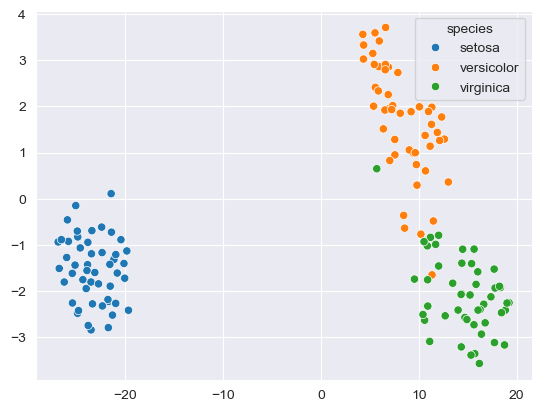

In [169]:
sns.scatterplot(x=transformed[:,0], y=transformed[:,1], hue=iris_df['species'])